# Final_Project_taap_p4

### Developed by:

- António Cruz (140129)
- Cátia Brás (120093)
- Ricardo Kyaseller (95813)

## 1. Introduction and Project Goals

gdgdgdgdgd

## 2. Environment, Reproducibility and Experimental Setup

### 2.1 Libraries Import

In [1]:
import os
import gc
import sys
import json
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import optuna
import psutil

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

I0000 00:00:1774604741.954419 1529622 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774604742.451230 1529622 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774604743.873223 1529622 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/ricarl/taap_p4/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found

### GPU Test

In [2]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1774604745.305979 1529622 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


### 2.2 Utils Configuration Test

In [3]:
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

/home/ricarl/taap_p4


In [4]:
from src.utils.env import set_global_seed, enable_gpu_memory_growth, get_device_info

SEED = 42
set_global_seed(SEED)
enable_gpu_memory_growth()

print(get_device_info())

{'tensorflow_version': '2.21.0', 'num_gpus': 1, 'gpus': ['/physical_device:GPU:0'], 'num_cpus': 1, 'cpus': ['/physical_device:CPU:0']}


## 3. Dataset and Problem Definition

### 3.1 Load Data

In [5]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "src" / "data"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("DATA_DIR exists?", DATA_DIR.exists())

PROJECT_ROOT: /home/ricarl/taap_p4
DATA_DIR: /home/ricarl/taap_p4/src/data
DATA_DIR exists? True


In [6]:
DATASET_PATH = DATA_DIR / "jena_climate_2009_2016.csv"

df = pd.read_csv(DATASET_PATH)
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


### 3.2 Initial Dataset Inspection

In [7]:
print("Dataset path:", DATASET_PATH)
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nInfo:")
df.info()

Dataset path: /home/ricarl/taap_p4/src/data/jena_climate_2009_2016.csv
Shape: (420551, 15)

Columns:
['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 420551 entries, 0 to 420550
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date Time        420551 non-null  str    
 1   p (mbar)         420551 non-null  float64
 2   T (degC)         420551 non-null  float64
 3   Tpot (K)         420551 non-null  float64
 4   Tdew (degC)      420551 non-null  float64
 5   rh (%)           420551 non-null  float64
 6   VPmax (mbar)     420551 non-null  float64
 7   VPact (mbar)     420551 non-null  float64
 8   VPdef (mbar)     420551 non-null  float64
 9   sh (g/kg)        420551 non-null  float64
 10  H2OC (mmol/

### 3.2 Data Quality Checks

In [8]:
print("Duplicated rows:", df.duplicated().sum())
print("\nMissing values per column:")
print(df.isna().sum())

Duplicated rows: 327

Missing values per column:
Date Time          0
p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64


In [9]:
df = df.drop_duplicates().copy()

print("Shape after removing duplicates:", df.shape)
print("Duplicated rows after cleanup:", df.duplicated().sum())

Shape after removing duplicates: (420224, 15)
Duplicated rows after cleanup: 0


### 3.3 Datetime Parsing and Temporal Ordering

In [10]:
df["Date Time"] = pd.to_datetime(df["Date Time"], dayfirst=True)
df = df.sort_values("Date Time").reset_index(drop=True)

print(df["Date Time"].min(), "->", df["Date Time"].max())
df[["Date Time"]].head()

2009-01-01 00:10:00 -> 2017-01-01 00:00:00


,Date Time
0,2009-01-01 00:10:00
1,2009-01-01 00:20:00
2,2009-01-01 00:30:00
3,2009-01-01 00:40:00
4,2009-01-01 00:50:00


In [11]:
df["Date Time"].diff().value_counts().head(10)

Date Time
0 days 00:10:00    420218
0 days 00:20:00         2
0 days 00:30:00         1
0 days 16:00:00         1
3 days 02:20:00         1
Name: count, dtype: int64

### 3.4 Hourly Resampling

In [12]:
df_hourly = (
    df.set_index("Date Time")
      .resample("1h")
      .mean()
      .reset_index()
)

print("Original shape:", df.shape)
print("Hourly shape:", df_hourly.shape)
print(df_hourly.head())

Original shape: (420224, 15)
Hourly shape: (70129, 15)
            Date Time    p (mbar)  T (degC)    Tpot (K)  Tdew (degC)  \
0 2009-01-01 00:00:00  996.528000 -8.304000  265.118000    -9.120000   
1 2009-01-01 01:00:00  996.525000 -8.065000  265.361667    -8.861667   
2 2009-01-01 02:00:00  996.745000 -8.763333  264.645000    -9.610000   
3 2009-01-01 03:00:00  996.986667 -8.896667  264.491667    -9.786667   
4 2009-01-01 04:00:00  997.158333 -9.348333  264.026667   -10.345000   

      rh (%)  VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  \
0  93.780000      3.260000      3.058000      0.202000   1.910000   
1  93.933333      3.323333      3.121667      0.201667   1.951667   
2  93.533333      3.145000      2.940000      0.201667   1.836667   
3  93.200000      3.111667      2.898333      0.210000   1.811667   
4  92.383333      3.001667      2.775000      0.231667   1.733333   

   H2OC (mmol/mol)  rho (g/m**3)  wv (m/s)  max. wv (m/s)    wd (deg)  
0         3.068000   1309

### 3.5 Post-Resampling Quality Check

In [13]:
print("Missing values after hourly resampling:")
print(df_hourly.isna().sum())

print("\nDuplicated timestamps after resampling:", df_hourly["Date Time"].duplicated().sum())

print("\nTime step distribution after resampling:")
print(df_hourly["Date Time"].diff().value_counts().head(10))

Missing values after hourly resampling:
Date Time           0
p (mbar)           88
T (degC)           88
Tpot (K)           88
Tdew (degC)        88
rh (%)             88
VPmax (mbar)       88
VPact (mbar)       88
VPdef (mbar)       88
sh (g/kg)          88
H2OC (mmol/mol)    88
rho (g/m**3)       88
wv (m/s)           88
max. wv (m/s)      88
wd (deg)           88
dtype: int64

Duplicated timestamps after resampling: 0

Time step distribution after resampling:
Date Time
0 days 01:00:00    70128
Name: count, dtype: int64


### 3.6 Handling Missing Values After Resampling

In [14]:
df_hourly = df_hourly.dropna().reset_index(drop=True)

print("Shape after dropping NaNs:", df_hourly.shape)
print("\nMissing values after cleanup:")
print(df_hourly.isna().sum().sum())
print("\nTime step distribution after cleanup:")
print(df_hourly["Date Time"].diff().value_counts().head())

Shape after dropping NaNs: (70041, 15)

Missing values after cleanup:
0

Time step distribution after cleanup:
Date Time
0 days 01:00:00    70038
0 days 16:00:00        1
3 days 02:00:00        1
Name: count, dtype: int64


### 3.7 Forecasting Task and Variable Selection

In [15]:
selected_columns = [
    "Date Time",
    "T (degC)",
    "p (mbar)",
    "rh (%)",
    "wv (m/s)",
    "max. wv (m/s)",
    "wd (deg)"
]

df_model = df_hourly[selected_columns].copy()

print("Selected columns:")
print(df_model.columns.tolist())
print("\nShape:", df_model.shape)
df_model.head()

Selected columns:
['Date Time', 'T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']

Shape: (70041, 7)


,Date Time,T (degC),p (mbar),rh (%),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:00:00,-8.304000,996.528000,93.780000,0.520000,1.002000,174.460000
1,2009-01-01 01:00:00,-8.065000,996.525000,93.933333,0.316667,0.711667,172.416667
2,2009-01-01 02:00:00,-8.763333,996.745000,93.533333,0.248333,0.606667,196.816667
3,2009-01-01 03:00:00,-8.896667,996.986667,93.200000,0.176667,0.606667,157.083333
4,2009-01-01 04:00:00,-9.348333,997.158333,92.383333,0.290000,0.670000,150.093333


## 4. Data Initial Preparation

### 4.1 Target Definition and Base Modeling DataFrame

In [16]:
TARGET_COL = "T (degC)"
TIME_COL = "Date Time"

feature_cols = [col for col in df_model.columns if col not in [TIME_COL]]
input_feature_cols = [col for col in feature_cols]

print("Target:", TARGET_COL)
print("Time column:", TIME_COL)
print("Input features:", input_feature_cols)
print("Number of input features:", len(input_feature_cols))

Target: T (degC)
Time column: Date Time
Input features: ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
Number of input features: 6


### 4.2 Base Forecasting Data Overview

In [17]:
print(df_model.head())
print("\nShape:", df_model.shape)
print("\nDate range:", df_model[TIME_COL].min(), "->", df_model[TIME_COL].max())

            Date Time  T (degC)    p (mbar)     rh (%)  wv (m/s)  \
0 2009-01-01 00:00:00 -8.304000  996.528000  93.780000  0.520000   
1 2009-01-01 01:00:00 -8.065000  996.525000  93.933333  0.316667   
2 2009-01-01 02:00:00 -8.763333  996.745000  93.533333  0.248333   
3 2009-01-01 03:00:00 -8.896667  996.986667  93.200000  0.176667   
4 2009-01-01 04:00:00 -9.348333  997.158333  92.383333  0.290000   

   max. wv (m/s)    wd (deg)  
0       1.002000  174.460000  
1       0.711667  172.416667  
2       0.606667  196.816667  
3       0.606667  157.083333  
4       0.670000  150.093333  

Shape: (70041, 7)

Date range: 2009-01-01 00:00:00 -> 2017-01-01 00:00:00


## 5. Feature Engineering

In [18]:
from src.features.engineering import (
    add_time_features,
    add_wind_features,
    get_final_feature_columns,
)
from src.features.windowing import make_windows
from src.models.gru import build_gru_model

### 5.1 Cyclical Time Features

In [19]:
df_feat = add_time_features(df_model, time_col=TIME_COL)

df_feat[[
    TIME_COL, "hour", "dayofyear",
    "hour_sin", "hour_cos", "doy_sin", "doy_cos"
]].head()

,Date Time,hour,dayofyear,hour_sin,hour_cos,doy_sin,doy_cos
0,2009-01-01 00:00:00,0,1,0.000000,1.000000,0.017202,0.999852
1,2009-01-01 01:00:00,1,1,0.258819,0.965926,0.017202,0.999852
2,2009-01-01 02:00:00,2,1,0.500000,0.866025,0.017202,0.999852
3,2009-01-01 03:00:00,3,1,0.707107,0.707107,0.017202,0.999852
4,2009-01-01 04:00:00,4,1,0.866025,0.500000,0.017202,0.999852


### 5.2 Wind-Derived Features

In [20]:
df_feat = add_wind_features(df_feat)

df_feat[[
    TIME_COL, "wv (m/s)", "max. wv (m/s)", "wd (deg)",
    "wd_sin", "wd_cos", "wx", "wy", "wind_gap", "gust_ratio"
]].head()

,Date Time,wv (m/s),max. wv (m/s),wd (deg),wd_sin,wd_cos,wx,wy,wind_gap,gust_ratio
0,2009-01-01 00:00:00,0.520000,1.002000,174.460000,0.096541,-0.995329,-0.517571,0.050201,0.482000,1.926919
1,2009-01-01 01:00:00,0.316667,0.711667,172.416667,0.131968,-0.991254,-0.313897,0.041790,0.395000,2.247361
2,2009-01-01 02:00:00,0.248333,0.606667,196.816667,-0.289310,-0.957235,-0.237713,-0.071845,0.358333,2.442943
3,2009-01-01 03:00:00,0.176667,0.606667,157.083333,0.389392,-0.921072,-0.162723,0.068793,0.430000,3.433943
4,2009-01-01 04:00:00,0.290000,0.670000,150.093333,0.498589,-0.866839,-0.251383,0.144591,0.380000,2.310337


### 5.3 Final Feature Set for Modeling

In [21]:
final_feature_cols = get_final_feature_columns()

print("Number of modeling features:", len(final_feature_cols))
print(final_feature_cols)

Number of modeling features: 16
['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'wd_sin', 'wd_cos', 'wx', 'wy', 'wind_gap', 'gust_ratio']


## 6. Split, Scaling and Windowing

### 6.1 Temporal Train/Validation/Test Split

In [22]:
n = len(df_feat)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

df_train = df_feat.iloc[:train_end].copy()
df_val = df_feat.iloc[train_end:val_end].copy()
df_test = df_feat.iloc[val_end:].copy()

print("Train shape:", df_train.shape)
print("Validation shape:", df_val.shape)
print("Test shape:", df_test.shape)

Train shape: (49028, 19)
Validation shape: (10506, 19)
Test shape: (10507, 19)


### 6.2 Feature Scaling

In [23]:
from src.features.scaling import get_scaler

In [24]:
SCALER_NAME = "standard"   # baseline oficial; no EA poderá ser standard/robust/minmax
scaler = get_scaler(SCALER_NAME)

X_train_df = df_train[final_feature_cols].copy()
X_val_df = df_val[final_feature_cols].copy()
X_test_df = df_test[final_feature_cols].copy()

X_train_scaled = scaler.fit_transform(X_train_df)
X_val_scaled = scaler.transform(X_val_df)
X_test_scaled = scaler.transform(X_test_df)

print("Scaler:", SCALER_NAME)
print("Scaled train shape:", X_train_scaled.shape)
print("Scaled val shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaler: standard
Scaled train shape: (49028, 16)
Scaled val shape: (10506, 16)
Scaled test shape: (10507, 16)


### 6.3 Target Index for Forecasting

In [25]:
target_idx = final_feature_cols.index(TARGET_COL)

print("Target column:", TARGET_COL)
print("Target index:", target_idx)

Target column: T (degC)
Target index: 0


### 6.4 Supervised Windowing

In [26]:
from src.features.windowing import make_windows

In [27]:
LOOKBACK = 120
HORIZON = 24

X_train, y_train = make_windows(X_train_scaled, target_idx, LOOKBACK, HORIZON)
X_val, y_val = make_windows(X_val_scaled, target_idx, LOOKBACK, HORIZON)
X_test, y_test = make_windows(X_test_scaled, target_idx, LOOKBACK, HORIZON)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (48885, 120, 16) y_train: (48885, 24)
X_val: (10363, 120, 16) y_val: (10363, 24)
X_test: (10364, 120, 16) y_test: (10364, 24)


### 6.5 Windowed Data Sanity Check

In [28]:
print("Input shape:", X_train.shape[1:])
print("Forecast horizon:", y_train.shape[1])
print("Number of input features:", X_train.shape[2])

print("\nExample input window shape:", X_train[0].shape)
print("Example target shape:", y_train[0].shape)
print("First 5 target values (scaled):", y_train[0][:5])

Input shape: (120, 16)
Forecast horizon: 24
Number of input features: 16

Example input window shape: (120, 16)
Example target shape: (24,)
First 5 target values (scaled): [-2.55218147 -2.61156348 -2.64453206 -2.68540539 -2.73726824]


## 7. Baseline Models

### 7.1 Persistence Baseline

In [29]:
def persistence_forecast(X):
    # Repeats the last observed target value across the full forecast horizon
    last_temp = X[:, -1, target_idx]
    return np.repeat(last_temp[:, None], HORIZON, axis=1)

y_pred_persistence = persistence_forecast(X_test)

print("Persistence prediction shape:", y_pred_persistence.shape)
print("First prediction:", y_pred_persistence[0][:5])

Persistence prediction shape: (10364, 24)
First prediction: [-0.04174932 -0.04174932 -0.04174932 -0.04174932 -0.04174932]


In [30]:
persistence_mae_scaled = mean_absolute_error(y_test.flatten(), y_pred_persistence.flatten())
persistence_rmse_scaled = np.sqrt(mean_squared_error(y_test.flatten(), y_pred_persistence.flatten()))

print("Persistence MAE (scaled):", persistence_mae_scaled)
print("Persistence RMSE (scaled):", persistence_rmse_scaled)

Persistence MAE (scaled): 0.3636531434000367
Persistence RMSE (scaled): 0.4921206134926399


In [31]:
def build_gru_baseline(input_shape, horizon):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.GRU(64, return_sequences=False),
        layers.Dropout(0.2),
        layers.Dense(64, activation="relu"),
        layers.Dense(horizon)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"]
    )
    return model

gru_baseline = build_gru_baseline(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    horizon=HORIZON
)

gru_baseline.summary()

W0000 00:00:1774604747.125302 1529622 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1774604747.240348 1529622 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 29127 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5090, pci bus id: 0000:02:00.0, compute capability: 12.0a


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        15,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,464 (83.84 KB)

 Trainable params: 21,464 (83.84 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_baseline = gru_baseline.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30


I0000 00:00:1774604749.151378 1529792 cuda_dnn.cc:461] Loaded cuDNN version 92000


764/764 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.1371 - mae: 0.2715 - val_loss: 0.0785 - val_mae: 0.2120
Epoch 2/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0831 - mae: 0.2212 - val_loss: 0.0737 - val_mae: 0.2043
Epoch 3/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0771 - mae: 0.2125 - val_loss: 0.0725 - val_mae: 0.2019
Epoch 4/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0732 - mae: 0.2064 - val_loss: 0.0713 - val_mae: 0.1996
Epoch 5/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0700 - mae: 0.2017 - val_loss: 0.0719 - val_mae: 0.1995
Epoch 6/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0673 - mae: 0.1979 - val_loss: 0.0724 - val_mae: 0.1998
Epoch 7/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0647 - mae: 0.1944 - val_loss: 0.0749 - val_mae: 0.2039
Epoch 8/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0619 - mae: 0.1904 - val_loss: 0.0751 - val_mae: 0.2023
Epoch 9/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - los

In [33]:
y_pred_gru = gru_baseline.predict(X_test, verbose=0)

print("Prediction shape:", y_pred_gru.shape)
print("First prediction:", y_pred_gru[0][:5])

Prediction shape: (10364, 24)
First prediction: [-0.1396297  -0.19604117 -0.15869606 -0.10635667 -0.00168435]


In [34]:
gru_mae_scaled = mean_absolute_error(y_test.flatten(), y_pred_gru.flatten())
gru_rmse_scaled = np.sqrt(mean_squared_error(y_test.flatten(), y_pred_gru.flatten()))

print("GRU MAE (scaled):", gru_mae_scaled)
print("GRU RMSE (scaled):", gru_rmse_scaled)

GRU MAE (scaled): 0.19167468050340655
GRU RMSE (scaled): 0.25372897313885967


### 7.2 GRU Baseline

In [35]:
from src.models.gru import build_gru_model

In [36]:
BASELINE_CFG = {
    "n_layers": 2,
    "units1": 96,
    "units2": 64,
    "units3": 96,
    "dropout": 0.0,
    "l2": 1e-6,
    "dense_units": 256,
    "dense_activation": "relu",
    "learning_rate": 2e-4,
    "clipnorm": 2.0,
    "optimizer_name": "adamw",
    "weight_decay": 1e-6,
    "loss_name": "huber1",
    "gaussian_noise_std": 0.0,
    "batch_size": 128,
}

gru_baseline = build_gru_model(
    L=LOOKBACK,
    n_features=X_train.shape[2],
    H=HORIZON,
    units1=BASELINE_CFG["units1"],
    units2=BASELINE_CFG["units2"],
    units3=BASELINE_CFG["units3"],
    n_layers=BASELINE_CFG["n_layers"],
    dropout=BASELINE_CFG["dropout"],
    l2=BASELINE_CFG["l2"],
    dense_units=BASELINE_CFG["dense_units"],
    dense_activation=BASELINE_CFG["dense_activation"],
    learning_rate=BASELINE_CFG["learning_rate"],
    clipnorm=BASELINE_CFG["clipnorm"],
    optimizer_name=BASELINE_CFG["optimizer_name"],
    weight_decay=BASELINE_CFG["weight_decay"],
    loss_name=BASELINE_CFG["loss_name"],
    gaussian_noise_std=BASELINE_CFG["gaussian_noise_std"],
)

gru_baseline.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 120, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 120, 96)        │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,744 (338.84 KB)

 Trainable params: 86,744 (338.84 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
from src.models.train_eval import (
    train_model,
    evaluate_scaled_forecasts,
    inverse_scale_target,
    evaluate_original_scale_forecasts,
)

In [38]:
history_baseline = train_model(
    model=gru_baseline,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    batch_size=BASELINE_CFG["batch_size"],
    epochs=60,
    verbose=1
)

Epoch 1/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0913 - mae: 0.3121 - val_loss: 0.0442 - val_mae: 0.2286 - learning_rate: 2.0000e-04
Epoch 2/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0397 - mae: 0.2158 - val_loss: 0.0403 - val_mae: 0.2159 - learning_rate: 2.0000e-04
Epoch 3/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0371 - mae: 0.2072 - val_loss: 0.0389 - val_mae: 0.2110 - learning_rate: 2.0000e-04
Epoch 4/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0356 - mae: 0.2023 - val_loss: 0.0380 - val_mae: 0.2080 - learning_rate: 2.0000e-04
Epoch 5/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0345 - mae: 0.1985 - val_loss: 0.0373 - val_mae: 0.2056 - learning_rate: 2.0000e-04
Epoch 6/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0336 - mae: 0.1954 - val_loss: 0.0367 - val_mae: 0.2037 - learning_rate: 2.0000e-04
Epoch 7/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0328 - mae: 0.1925 - val_loss: 0.0363 - val_mae: 0.2022

In [39]:
y_pred_gru = gru_baseline.predict(X_test, verbose=0)

print("Prediction shape:", y_pred_gru.shape)
print("First prediction:", y_pred_gru[0][:12])

Prediction shape: (10364, 24)
First prediction: [-0.12772319 -0.14138252 -0.10323998 -0.08130974 -0.02316401  0.05356833
  0.13417064  0.2621488   0.28543547  0.31266397  0.29689935  0.22027066]


In [40]:
gru_scaled_metrics = evaluate_scaled_forecasts(y_test, y_pred_gru)

gru_mae_scaled = gru_scaled_metrics["mae_scaled"]
gru_rmse_scaled = gru_scaled_metrics["rmse_scaled"]

print("GRU Baseline MAE (scaled):", gru_mae_scaled)
print("GRU Baseline RMSE (scaled):", gru_rmse_scaled)

GRU Baseline MAE (scaled): 0.19260359695534202
GRU Baseline RMSE (scaled): 0.25550325168267907


### 7.3 Baseline Comparison

In [41]:
baseline_results_scaled = pd.DataFrame({
    "Model": ["Persistence", "GRU Baseline Official"],
    "MAE_scaled": [persistence_mae_scaled, gru_mae_scaled],
    "RMSE_scaled": [persistence_rmse_scaled, gru_rmse_scaled],
})

baseline_results_scaled

,Model,MAE_scaled,RMSE_scaled
0,Persistence,0.363653,0.492121
1,GRU Baseline Official,0.192604,0.255503


### 7.4 Reverse Scaling

In [42]:
target_mean = scaler.mean_[target_idx]
target_std = scaler.scale_[target_idx]

y_test_inv = inverse_scale_target(y_test, target_mean, target_std)
y_pred_persistence_inv = inverse_scale_target(y_pred_persistence, target_mean, target_std)
y_pred_gru_inv = inverse_scale_target(y_pred_gru, target_mean, target_std)

print("y_test_inv shape:", y_test_inv.shape)
print("y_pred_gru_inv shape:", y_pred_gru_inv.shape)

y_test_inv shape: (10364, 24)
y_pred_gru_inv shape: (10364, 24)


### 7.5 Baseline Evaluation in Original Temperature Scale

In [43]:
gru_original_metrics = evaluate_original_scale_forecasts(y_test_inv, y_pred_gru_inv)
persistence_original_metrics = evaluate_original_scale_forecasts(y_test_inv, y_pred_persistence_inv)

gru_mae = gru_original_metrics["mae"]
gru_rmse = gru_original_metrics["rmse"]

persistence_mae = persistence_original_metrics["mae"]
persistence_rmse = persistence_original_metrics["rmse"]

print("GRU Baseline MAE (°C):", gru_mae)
print("GRU Baseline RMSE (°C):", gru_rmse)

GRU Baseline MAE (°C): 1.6649798973137924
GRU Baseline RMSE (°C): 2.208721874745694


### 7.6 Final Baseline Comparison

In [44]:
baseline_results = pd.DataFrame({
    "Model": ["Persistence", "GRU Baseline Official"],
    "MAE_scaled": [persistence_mae_scaled, gru_mae_scaled],
    "RMSE_scaled": [persistence_rmse_scaled, gru_rmse_scaled],
    "MAE_degC": [persistence_mae, gru_mae],
    "RMSE_degC": [persistence_rmse, gru_rmse],
})

baseline_results

,Model,MAE_scaled,RMSE_scaled,MAE_degC,RMSE_degC
0,Persistence,0.363653,0.492121,3.143634,4.254183
1,GRU Baseline Official,0.192604,0.255503,1.664980,2.208722


### 7.6 Example Forecast Visualization

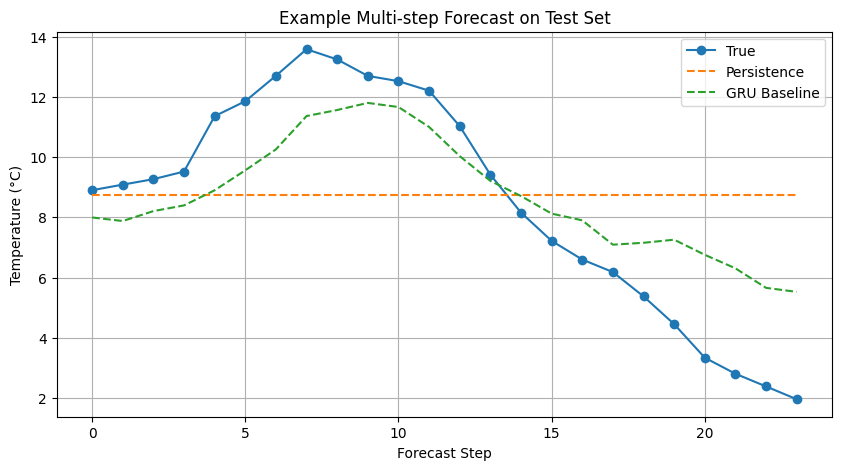

In [45]:
sample_idx = 0

plt.figure(figsize=(10, 5))
plt.plot(y_test_inv[sample_idx], label="True", marker="o")
plt.plot(y_pred_persistence_inv[sample_idx], label="Persistence", linestyle="--")
plt.plot(y_pred_gru_inv[sample_idx], label="GRU Baseline", linestyle="--")
plt.title("Example Multi-step Forecast on Test Set")
plt.xlabel("Forecast Step")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

## 8. Synthetic Data Generation with TimeGAN

### 8.1 Motivation and Experimental Role

The goal of the TimeGAN component is to generate realistic synthetic multivariate weather sequences using only the training split, avoiding any form of data leakage. 

These synthetic sequences will later be used to augment the training data and assess whether data augmentation improves forecasting performance, robustness, or generalization.

To keep the setup consistent with the forecasting task, the synthetic generator is trained on multivariate sequences of length `LOOKBACK + HORIZON`, so that each generated sequence can later be split into:
- an input window of length `LOOKBACK`
- a target forecasting horizon of length `HORIZON`

The impact of synthetic augmentation will be evaluated by comparing forecasting models trained with:
1. real data only
2. real data plus synthetic data

### 8.2 TimeGAN Training Data Preparation

In [46]:
from src.gan.data_prep import make_timegan_sequences, split_synthetic_sequences

TIMEGAN_SEQ_LEN = LOOKBACK + HORIZON

timegan_train_sequences = make_timegan_sequences(X_train_scaled, TIMEGAN_SEQ_LEN)

print("TimeGAN sequence length:", TIMEGAN_SEQ_LEN)
print("TimeGAN training sequences shape:", timegan_train_sequences.shape)

TimeGAN sequence length: 144
TimeGAN training sequences shape: (48885, 144, 16)


### 8.3 TimeGAN Model and Training Procedure

In [47]:
from src.gan.config import TIMEGAN_CONFIG
from src.gan.timegan import TimeGAN

TIMEGAN_CONFIG["seq_len"] = TIMEGAN_SEQ_LEN

timegan = TimeGAN(
    seq_len=TIMEGAN_CONFIG["seq_len"],
    n_features=timegan_train_sequences.shape[2],
    hidden_dim=TIMEGAN_CONFIG["hidden_dim"],
    num_layers=TIMEGAN_CONFIG["num_layers"],
    learning_rate=TIMEGAN_CONFIG["learning_rate"],
    gamma=TIMEGAN_CONFIG["gamma"],
)

print(TIMEGAN_CONFIG)
print("TimeGAN input shape:", timegan_train_sequences.shape)

{'seq_len': 144, 'hidden_dim': 24, 'num_layers': 3, 'batch_size': 128, 'ae_epochs': 20, 'sup_epochs': 20, 'adv_epochs': 15, 'learning_rate': 0.001, 'gamma': 1.0}
TimeGAN input shape: (48885, 144, 16)


In [48]:
timegan.summary()


=== Embedder ===


Model: "embedder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 144, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedder_gru_1 (GRU)            │ (None, 144, 24)        │         3,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedder_gru_2 (GRU)            │ (None, 144, 24)        │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedder_gru_3 (GRU)            │ (None, 144, 24)        │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedder_out (TimeDistributed)  │ (None, 144, 24)        │           600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,824 (42.28 KB)

 Trainable params: 10,824 (42.28 KB)

...

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 144, 24)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ discriminator_gru_1 (GRU)       │ (None, 144, 24)        │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ discriminator_gru_2 (GRU)       │ (None, 144, 24)        │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ discriminator_gru_3 (GRU)       │ (None, 144, 24)        │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ discriminator_out               │ (None, 144, 1)         │            25 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,825 (42.29 KB)

 Trainable params: 10,825 (42.29 KB)

 Non-trainable params: 0 (0.00 B)

#### 8.3.1 Autoencoder Pretraining

In [49]:
autoencoder_history = timegan.pretrain_autoencoder(
    sequences=timegan_train_sequences,
    epochs=TIMEGAN_CONFIG["ae_epochs"],
    batch_size=TIMEGAN_CONFIG["batch_size"],
    verbose=1,
)

Epoch 1/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 32s 73ms/step - loss: 0.2804
Epoch 2/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - loss: 0.0531
Epoch 3/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 26s 69ms/step - loss: 0.0266
Epoch 4/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 25s 66ms/step - loss: 0.0180
Epoch 5/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - loss: 0.0137
Epoch 6/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - loss: 0.0109
Epoch 7/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 27s 72ms/step - loss: 0.0091
Epoch 8/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 27s 70ms/step - loss: 0.0078
Epoch 9/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - loss: 0.0068
Epoch 10/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - loss: 0.0059
Epoch 11/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 27s 70ms/step - loss: 0.0053
Epoch 12/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 28s 74ms/step - loss: 0.0048
Epoch 13/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 27s 71ms/step - loss: 0.0044
Epoch 14/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - loss: 0.0038
Epoch 15/20
382/382 ━━━━━━━━━

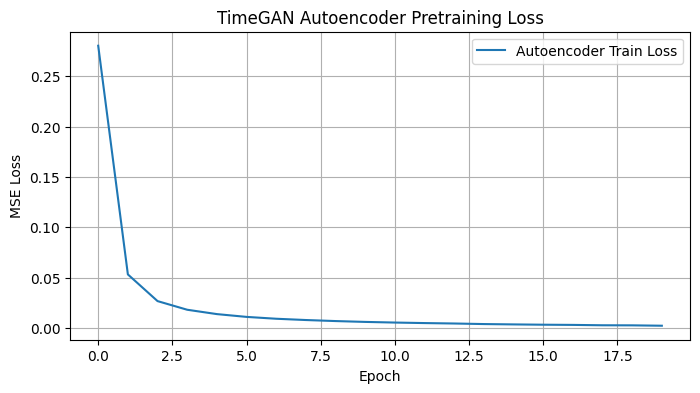

In [50]:
plt.figure(figsize=(8, 4))
plt.plot(autoencoder_history.history["loss"], label="Autoencoder Train Loss")
plt.title("TimeGAN Autoencoder Pretraining Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.legend()
plt.show()

#### 8.3.2 Supervisor Pretraining

In [51]:
supervisor_history = timegan.pretrain_supervisor(
    sequences=timegan_train_sequences,
    epochs=TIMEGAN_CONFIG["sup_epochs"],
    batch_size=TIMEGAN_CONFIG["batch_size"],
    verbose=1,
)

Epoch 1/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - loss: 0.0307
Epoch 2/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - loss: 0.0112
Epoch 3/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - loss: 0.0094
Epoch 4/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - loss: 0.0087
Epoch 5/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - loss: 0.0083
Epoch 6/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - loss: 0.0081
Epoch 7/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - loss: 0.0080
Epoch 8/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - loss: 0.0079
Epoch 9/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - loss: 0.0079
Epoch 10/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.0078
Epoch 11/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - loss: 0.0078
Epoch 12/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.0078
Epoch 13/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - loss: 0.0077
Epoch 14/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - loss: 0.0077
Epoch 15/20
382/382 ━━━━━━━━━

#### 8.3.3 Pretraining Loss Curves

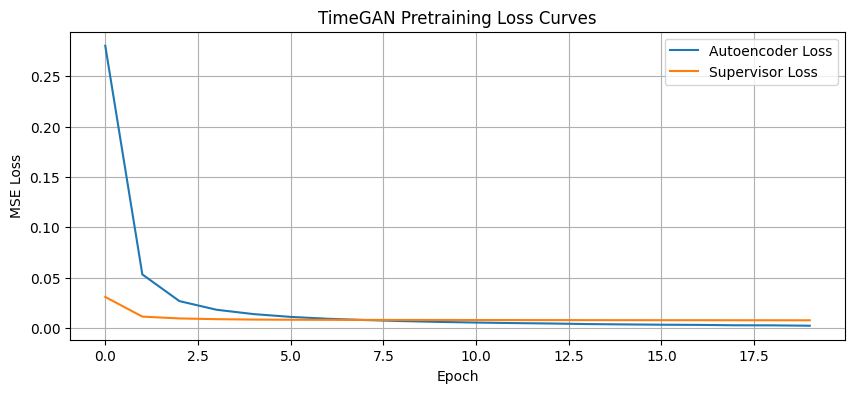

In [52]:
plt.figure(figsize=(10, 4))
plt.plot(autoencoder_history.history["loss"], label="Autoencoder Loss")
plt.plot(supervisor_history.history["loss"], label="Supervisor Loss")
plt.title("TimeGAN Pretraining Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.legend()
plt.show()

#### 8.3.4 Adversarial Training 

In [53]:
adversarial_history = timegan.fit(
    sequences=timegan_train_sequences,
    epochs=TIMEGAN_CONFIG["adv_epochs"],
    batch_size=TIMEGAN_CONFIG["batch_size"],
    verbose=1,
)

Epoch 1/15 - d_loss: 1.3640 - g_loss: 4.5428 - g_loss_u: 0.7551 - g_loss_s: 0.0260 - g_loss_v: 1.1885
Epoch 2/15 - d_loss: 1.1869 - g_loss: 3.8648 - g_loss_u: 1.0885 - g_loss_s: 0.0153 - g_loss_v: 1.2495
Epoch 3/15 - d_loss: 0.9773 - g_loss: 4.0989 - g_loss_u: 1.4651 - g_loss_s: 0.0127 - g_loss_v: 1.3670
Epoch 4/15 - d_loss: 0.2506 - g_loss: 5.4339 - g_loss_u: 2.9779 - g_loss_s: 0.0108 - g_loss_v: 1.3758
Epoch 5/15 - d_loss: 0.1376 - g_loss: 5.3876 - g_loss_u: 3.2437 - g_loss_s: 0.0098 - g_loss_v: 1.1625
Epoch 6/15 - d_loss: 0.1377 - g_loss: 5.2274 - g_loss_u: 3.2133 - g_loss_s: 0.0095 - g_loss_v: 1.0630
Epoch 7/15 - d_loss: 0.1371 - g_loss: 5.1799 - g_loss_u: 3.2069 - g_loss_s: 0.0093 - g_loss_v: 1.0476
Epoch 8/15 - d_loss: 0.1367 - g_loss: 5.1592 - g_loss_u: 3.2108 - g_loss_s: 0.0090 - g_loss_v: 1.0441
Epoch 9/15 - d_loss: 0.1346 - g_loss: 5.1668 - g_loss_u: 3.2393 - g_loss_s: 0.0089 - g_loss_v: 1.0413
Epoch 10/15 - d_loss: 0.1355 - g_loss: 5.1360 - g_loss_u: 3.2275 - g_loss_s: 0.008

#### 8.3.5 Adversarial Training Loss Curves

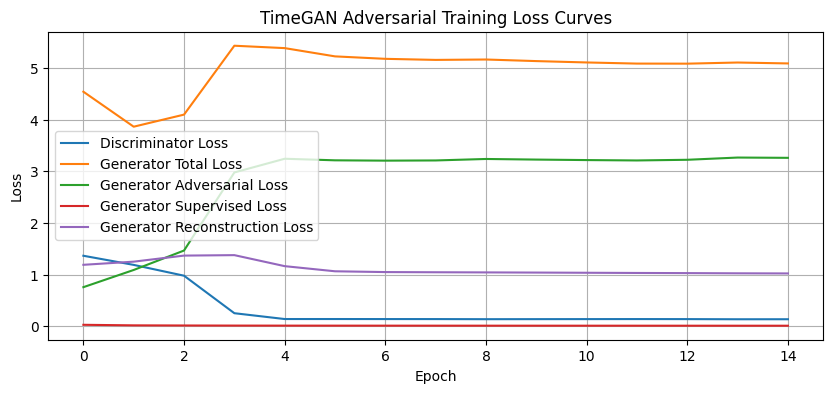

In [54]:
plt.figure(figsize=(10, 4))
plt.plot(adversarial_history["d_loss"], label="Discriminator Loss")
plt.plot(adversarial_history["g_loss"], label="Generator Total Loss")
plt.plot(adversarial_history["g_loss_u"], label="Generator Adversarial Loss")
plt.plot(adversarial_history["g_loss_s"], label="Generator Supervised Loss")
plt.plot(adversarial_history["g_loss_v"], label="Generator Reconstruction Loss")
plt.title("TimeGAN Adversarial Training Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

### 8.4 Synthetic Sequence Quality Assessment

#### 8.4.1 Autoencoder Reconstruction Check

In [55]:
reconstructed_sequences = timegan.autoencoder.predict(
    timegan_train_sequences[:256],
    verbose=0
)

reconstruction_mse = np.mean((timegan_train_sequences[:256] - reconstructed_sequences) ** 2)

print("Reconstructed batch shape:", reconstructed_sequences.shape)
print("Reconstruction MSE on sample batch:", reconstruction_mse)

Reconstructed batch shape: (256, 144, 16)
Reconstruction MSE on sample batch: 0.0015123516227192751


#### 8.4.2 Real vs Reconstructed Sequence

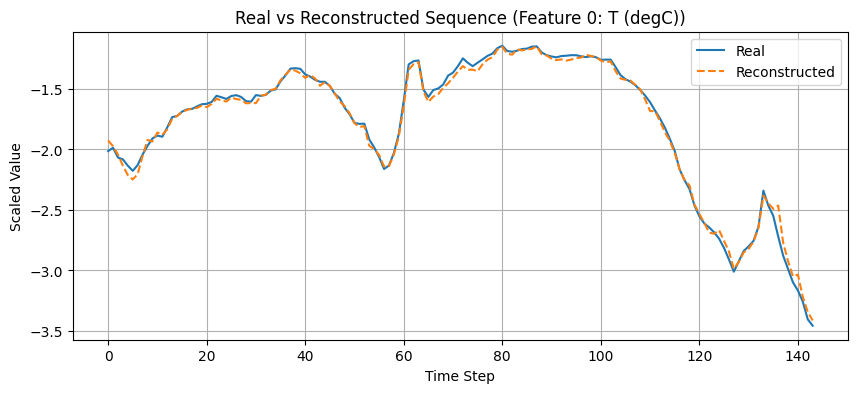

In [56]:
sample_idx = 0
feature_idx = 0  # T (degC)

plt.figure(figsize=(10, 4))
plt.plot(timegan_train_sequences[sample_idx, :, feature_idx], label="Real")
plt.plot(reconstructed_sequences[sample_idx, :, feature_idx], label="Reconstructed", linestyle="--")
plt.title("Real vs Reconstructed Sequence (Feature 0: T (degC))")
plt.xlabel("Time Step")
plt.ylabel("Scaled Value")
plt.grid(True)
plt.legend()
plt.show()

#### 8.4.3 Synthetic Sequence Preview

In [57]:
synthetic_sequences_preview = timegan.generate(8)

print("Synthetic preview shape:", synthetic_sequences_preview.shape)
print("Synthetic preview min:", synthetic_sequences_preview.min())
print("Synthetic preview max:", synthetic_sequences_preview.max())

Synthetic preview shape: (8, 144, 16)
Synthetic preview min: -1.6791376
Synthetic preview max: 1.3385307


#### 8.4.4 Real vs Synthetic Sequence

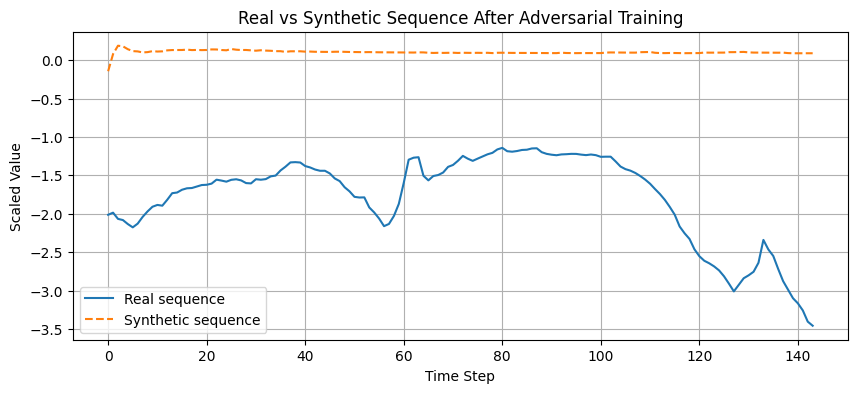

In [58]:
sample_idx = 0
feature_idx = 0  # T (degC)

plt.figure(figsize=(10, 4))
plt.plot(timegan_train_sequences[sample_idx, :, feature_idx], label="Real sequence")
plt.plot(synthetic_sequences_preview[sample_idx, :, feature_idx], label="Synthetic sequence", linestyle="--")
plt.title("Real vs Synthetic Sequence After Adversarial Training")
plt.xlabel("Time Step")
plt.ylabel("Scaled Value")
plt.grid(True)
plt.legend()
plt.show()

### 8.5 Augmented Training Set Construction

### 8.6 Forecasting Comparison With and Without Synthetic Data

## 9. Evolutionary Optimization of the Forecasting Pipeline

### 9.1 Motivation and Search Strategy

The evolutionary optimization stage aims to improve the forecasting pipeline beyond the fixed GRU baseline by exploring alternative architectural and training configurations.

Instead of relying on a single manually selected model or Bayesian optimization from the previous work, this stage uses a genetic search strategy based on:
- population initialization
- tournament selection
- crossover
- mutation
- elitism

Each candidate solution represents a full forecasting configuration, including GRU architecture, optimizer, loss, regularization, batch size, and scaling method. The fitness of each candidate is defined by validation forecasting performance on the scaled target series.

### 9.2 Search Space Definition

In [59]:
from src.evolution.search_space import SEARCH_SPACE

print("Search space keys:")
print(list(SEARCH_SPACE.keys()))

for k, v in SEARCH_SPACE.items():
    print(f"{k}: {v}")

Search space keys:
['n_layers', 'units1', 'units2', 'units3', 'dropout', 'l2', 'dense_units', 'dense_activation', 'learning_rate', 'batch_size', 'clipnorm', 'optimizer_name', 'weight_decay', 'loss_name', 'gaussian_noise_std', 'scaler_name']
n_layers: [1, 2]
units1: [64, 96, 128]
units2: [32, 64, 96, 128]
units3: [32, 64, 96]
dropout: [0.0, 0.1, 0.2, 0.3]
l2: [0.0, 1e-06, 1e-05, 0.0001]
dense_units: [0, 64, 128, 256]
dense_activation: ['relu', 'gelu', 'elu', 'leaky_relu']
learning_rate: [0.001, 0.0005, 0.0003, 0.0002, 0.0001]
batch_size: [128, 256]
clipnorm: [0.5, 1.0, 2.0, 5.0]
optimizer_name: ['adam', 'adamw']
weight_decay: [0.0, 1e-06, 1e-05, 0.0001]
loss_name: ['mse', 'mae', 'huber1', 'huber2']
gaussian_noise_std: [0.0, 0.01]
scaler_name: ['standard', 'robust', 'minmax']


### 9.3 Evolutionary Representation and Constraints

In [62]:
from src.evolution.genotype import sample_genotype

example_genotype = sample_genotype()
example_genotype

{'n_layers': 2,
 'units1': 96,
 'units2': 64,
 'units3': 64,
 'dropout': 0.2,
 'l2': 0.0,
 'dense_units': 64,
 'dense_activation': 'gelu',
 'learning_rate': 0.0005,
 'batch_size': 256,
 'clipnorm': 5.0,
 'optimizer_name': 'adamw',
 'weight_decay': 1e-06,
 'loss_name': 'huber1',
 'gaussian_noise_std': 0.0,
 'scaler_name': 'standard'}

### 9.4 Fitness Function

The fitness of each individual is defined as the validation MAE on the scaled forecasting target. 

For each candidate configuration, the pipeline performs:
1. feature scaling using the candidate scaler
2. supervised window generation
3. GRU model construction
4. model training on the training split
5. prediction on the validation split
6. computation of validation MAE in scaled space

The optimization objective is to minimize this validation forecasting error.

In [63]:
from src.evolution.fitness import evaluate_individual

example_result = evaluate_individual(
    cfg=example_genotype,
    df_train=df_train,
    df_val=df_val,
    final_feature_cols=final_feature_cols,
    target_idx=target_idx,
    lookback=LOOKBACK,
    horizon=HORIZON,
    epochs=20,
    verbose=0,
)

example_result

{'cfg': {'n_layers': 2,
  'units1': 96,
  'units2': 64,
  'units3': 64,
  'dropout': 0.2,
  'l2': 0.0,
  'dense_units': 64,
  'dense_activation': 'gelu',
  'learning_rate': 0.0005,
  'batch_size': 256,
  'clipnorm': 5.0,
  'optimizer_name': 'adamw',
  'weight_decay': 1e-06,
  'loss_name': 'huber1',
  'gaussian_noise_std': 0.0,
  'scaler_name': 'standard'},
 'fitness': 2.0228274590048945,
 'metrics': {'mae_scaled': 0.23399912830956554,
  'rmse_scaled': np.float64(0.30242250127687326),
  'mae_degC': 2.0228274590048945,
  'rmse_degC': np.float64(2.614319737954317)}}

### 9.5 Evolutionary Search Execution

In [64]:
from src.evolution.ga_evolutionary_search import run_evolutionary_search

best_result, evo_history = run_evolutionary_search(
    df_train=df_train,
    df_val=df_val,
    final_feature_cols=final_feature_cols,
    target_idx=target_idx,
    population_size=10,
    generations=7,
    mutation_rate=0.2,
    elitism=2,
    lookback=LOOKBACK,
    horizon=HORIZON,
    epochs=40,
    verbose=0,
)

best_result

Generation 1/7 - best fitness: 1.725298
Generation 2/7 - best fitness: 1.696989
Generation 3/7 - best fitness: 1.680815
Generation 4/7 - best fitness: 1.689676
Generation 5/7 - best fitness: 1.679928
Generation 6/7 - best fitness: 1.672974
Generation 7/7 - best fitness: 1.679512


{'cfg': {'n_layers': 2,
  'units1': 128,
  'units2': 96,
  'units3': 32,
  'dropout': 0.0,
  'l2': 1e-06,
  'dense_units': 64,
  'dense_activation': 'elu',
  'learning_rate': 0.0005,
  'batch_size': 128,
  'clipnorm': 5.0,
  'optimizer_name': 'adam',
  'weight_decay': 0.0,
  'loss_name': 'mae',
  'gaussian_noise_std': 0.0,
  'scaler_name': 'robust'},
 'fitness': 1.6729739649835822,
 'metrics': {'mae_scaled': 0.13560530635822207,
  'rmse_scaled': np.float64(0.18482620680112197),
  'mae_degC': 1.6729739649835822,
  'rmse_degC': np.float64(2.280216315489342)}}

### 9.6 Best Configuration and Retraining

In [65]:
best_cfg = best_result["cfg"]
best_cfg

{'n_layers': 2,
 'units1': 128,
 'units2': 96,
 'units3': 32,
 'dropout': 0.0,
 'l2': 1e-06,
 'dense_units': 64,
 'dense_activation': 'elu',
 'learning_rate': 0.0005,
 'batch_size': 128,
 'clipnorm': 5.0,
 'optimizer_name': 'adam',
 'weight_decay': 0.0,
 'loss_name': 'mae',
 'gaussian_noise_std': 0.0,
 'scaler_name': 'robust'}

In [66]:
evo_gru = build_gru_model(
    L=LOOKBACK,
    n_features=X_train.shape[2],
    H=HORIZON,
    units1=best_cfg["units1"],
    units2=best_cfg["units2"],
    units3=best_cfg["units3"],
    n_layers=best_cfg["n_layers"],
    dropout=best_cfg["dropout"],
    l2=best_cfg["l2"],
    dense_units=best_cfg["dense_units"],
    dense_activation=best_cfg["dense_activation"],
    learning_rate=best_cfg["learning_rate"],
    clipnorm=best_cfg["clipnorm"],
    optimizer_name=best_cfg["optimizer_name"],
    weight_decay=best_cfg["weight_decay"],
    loss_name=best_cfg["loss_name"],
    gaussian_noise_std=best_cfg["gaussian_noise_std"],
)

evo_gru.summary()

Model: "functional_73"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_83 (InputLayer)     │ (None, 120, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_124 (GRU)                   │ (None, 120, 128)       │        56,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_125 (GRU)                   │ (None, 96)             │        65,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_148 (Dense)               │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_69 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_149 (Dense)               │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,920 (503.59 KB)

 Trainable params: 128,920 (503.59 KB)

 Non-trainable params: 0 (0.00 B)

### 9.7 Top Candidate Configurations

In [67]:
top_results = []

for generation_results in evo_history:
    top_results.extend(generation_results)

top_results_sorted = sorted(top_results, key=lambda x: x["fitness"])

top_5_unique = []
seen = set()

for result in top_results_sorted:
    cfg_tuple = tuple(sorted(result["cfg"].items()))
    if cfg_tuple not in seen:
        seen.add(cfg_tuple)
        top_5_unique.append(result)
    if len(top_5_unique) == 5:
        break

top_5_df = pd.DataFrame([
    {
        **res["cfg"],
        "fitness_mae_degC": res["fitness"],
        "rmse_degC": res["metrics"]["rmse_degC"],
        "mae_scaled": res["metrics"]["mae_scaled"],
        "rmse_scaled": res["metrics"]["rmse_scaled"],
    }
    for res in top_5_unique
])

top_5_df

,n_layers,units1,units2,units3,dropout,l2,dense_units,dense_activation,learning_rate,batch_size,clipnorm,optimizer_name,weight_decay,loss_name,gaussian_noise_std,scaler_name,fitness_mae_degC,rmse_degC,mae_scaled,rmse_scaled
0,2,128,96,32,0.0,0.000001,64,elu,0.0005,128,5.0,adam,0.00000,mae,0.00,robust,1.672974,2.280216,0.135605,0.184826
1,2,128,128,32,0.0,0.000001,64,elu,0.0005,128,5.0,adamw,0.00001,mae,0.00,standard,1.679512,2.292414,0.194285,0.265185
2,2,128,32,32,0.0,0.000000,256,elu,0.0005,128,1.0,adam,0.00000,mae,0.00,minmax,1.680815,2.404593,0.028891,0.041331
3,2,128,32,32,0.0,0.000000,256,elu,0.0005,128,0.5,adam,0.00000,mae,0.01,standard,1.681025,2.280680,0.194460,0.263827
4,1,96,64,64,0.0,0.000001,128,elu,0.0005,128,0.5,adamw,0.00000,mae,0.01,standard,1.682993,2.286089,0.194687,0.264453


## 10. Retraining and Final Model Selection

### 10.1 Selection of Final Candidates

In [68]:
baseline_cfg_final = BASELINE_CFG.copy()
evolutionary_cfg_final = best_result["cfg"].copy()

final_candidates = pd.DataFrame([
    {"candidate": "GRU Baseline Official", **baseline_cfg_final},
    {"candidate": "Best Evolutionary GRU", **evolutionary_cfg_final},
])

final_candidates

,candidate,n_layers,units1,units2,units3,dropout,l2,dense_units,dense_activation,learning_rate,clipnorm,optimizer_name,weight_decay,loss_name,gaussian_noise_std,batch_size,scaler_name
0,GRU Baseline Official,2,96,64,96,0.0,0.000001,256,relu,0.0002,2.0,adamw,0.000001,huber1,0.0,128,NaN
1,Best Evolutionary GRU,2,128,96,32,0.0,0.000001,64,elu,0.0005,5.0,adam,0.000000,mae,0.0,128,robust


### 10.2 Retraining Procedure

In [69]:
baseline_cfg_final["scaler_name"] = "standard"
evolutionary_cfg_final["scaler_name"] = evolutionary_cfg_final.get("scaler_name", "standard")

print("Baseline final scaler:", baseline_cfg_final["scaler_name"])
print("Evolutionary final scaler:", evolutionary_cfg_final["scaler_name"])

Baseline final scaler: standard
Evolutionary final scaler: robust


In [70]:
def prepare_data_for_cfg(cfg, df_train, df_val, df_test, final_feature_cols, target_idx, lookback, horizon):
    scaler = get_scaler(cfg["scaler_name"])

    X_train_df = df_train[final_feature_cols].copy()
    X_val_df = df_val[final_feature_cols].copy()
    X_test_df = df_test[final_feature_cols].copy()

    X_train_scaled = scaler.fit_transform(X_train_df)
    X_val_scaled = scaler.transform(X_val_df)
    X_test_scaled = scaler.transform(X_test_df)

    X_train, y_train = make_windows(X_train_scaled, target_idx, lookback, horizon)
    X_val, y_val = make_windows(X_val_scaled, target_idx, lookback, horizon)
    X_test, y_test = make_windows(X_test_scaled, target_idx, lookback, horizon)

    return scaler, X_train, y_train, X_val, y_val, X_test, y_test

In [71]:
baseline_scaler, X_train_b, y_train_b, X_val_b, y_val_b, X_test_b, y_test_b = prepare_data_for_cfg(
    baseline_cfg_final,
    df_train,
    df_val,
    df_test,
    final_feature_cols,
    target_idx,
    LOOKBACK,
    HORIZON,
)

evo_scaler, X_train_e, y_train_e, X_val_e, y_val_e, X_test_e, y_test_e = prepare_data_for_cfg(
    evolutionary_cfg_final,
    df_train,
    df_val,
    df_test,
    final_feature_cols,
    target_idx,
    LOOKBACK,
    HORIZON,
)

print("Baseline train shape:", X_train_b.shape, y_train_b.shape)
print("Evolutionary train shape:", X_train_e.shape, y_train_e.shape)

Baseline train shape: (48885, 120, 16) (48885, 24)
Evolutionary train shape: (48885, 120, 16) (48885, 24)


In [72]:
baseline_final_model = build_gru_model(
    L=LOOKBACK,
    n_features=X_train_b.shape[2],
    H=HORIZON,
    units1=baseline_cfg_final["units1"],
    units2=baseline_cfg_final["units2"],
    units3=baseline_cfg_final["units3"],
    n_layers=baseline_cfg_final["n_layers"],
    dropout=baseline_cfg_final["dropout"],
    l2=baseline_cfg_final["l2"],
    dense_units=baseline_cfg_final["dense_units"],
    dense_activation=baseline_cfg_final["dense_activation"],
    learning_rate=baseline_cfg_final["learning_rate"],
    clipnorm=baseline_cfg_final["clipnorm"],
    optimizer_name=baseline_cfg_final["optimizer_name"],
    weight_decay=baseline_cfg_final["weight_decay"],
    loss_name=baseline_cfg_final["loss_name"],
    gaussian_noise_std=baseline_cfg_final["gaussian_noise_std"],
)

evolutionary_final_model = build_gru_model(
    L=LOOKBACK,
    n_features=X_train_e.shape[2],
    H=HORIZON,
    units1=evolutionary_cfg_final["units1"],
    units2=evolutionary_cfg_final["units2"],
    units3=evolutionary_cfg_final["units3"],
    n_layers=evolutionary_cfg_final["n_layers"],
    dropout=evolutionary_cfg_final["dropout"],
    l2=evolutionary_cfg_final["l2"],
    dense_units=evolutionary_cfg_final["dense_units"],
    dense_activation=evolutionary_cfg_final["dense_activation"],
    learning_rate=evolutionary_cfg_final["learning_rate"],
    clipnorm=evolutionary_cfg_final["clipnorm"],
    optimizer_name=evolutionary_cfg_final["optimizer_name"],
    weight_decay=evolutionary_cfg_final["weight_decay"],
    loss_name=evolutionary_cfg_final["loss_name"],
    gaussian_noise_std=evolutionary_cfg_final["gaussian_noise_std"],
)

print("Baseline final model:")
baseline_final_model.summary()

print("\nEvolutionary final model:")
evolutionary_final_model.summary()

Baseline final model:


Model: "functional_74"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_84 (InputLayer)     │ (None, 120, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_126 (GRU)                   │ (None, 120, 96)        │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_127 (GRU)                   │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_150 (Dense)               │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_70 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_151 (Dense)               │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,744 (338.84 KB)

 Trainable params: 86,744 (338.84 KB)

...

Model: "functional_75"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_85 (InputLayer)     │ (None, 120, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_128 (GRU)                   │ (None, 120, 128)       │        56,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_129 (GRU)                   │ (None, 96)             │        65,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_152 (Dense)               │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_71 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_153 (Dense)               │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,920 (503.59 KB)

 Trainable params: 128,920 (503.59 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
baseline_final_history = train_model(
    model=baseline_final_model,
    X_train=X_train_b,
    y_train=y_train_b,
    X_val=X_val_b,
    y_val=y_val_b,
    batch_size=baseline_cfg_final["batch_size"],
    epochs=30,
    verbose=1,
)

Epoch 1/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.0913 - mae: 0.3127 - val_loss: 0.0447 - val_mae: 0.2304 - learning_rate: 2.0000e-04
Epoch 2/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0401 - mae: 0.2171 - val_loss: 0.0407 - val_mae: 0.2172 - learning_rate: 2.0000e-04
Epoch 3/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0373 - mae: 0.2081 - val_loss: 0.0392 - val_mae: 0.2120 - learning_rate: 2.0000e-04
Epoch 4/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.0358 - mae: 0.2029 - val_loss: 0.0384 - val_mae: 0.2090 - learning_rate: 2.0000e-04
Epoch 5/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0347 - mae: 0.1991 - val_loss: 0.0378 - val_mae: 0.2069 - learning_rate: 2.0000e-04
Epoch 6/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0338 - mae: 0.1959 - val_loss: 0.0374 - val_mae: 0.2052 - learning_rate: 2.0000e-04
Epoch 7/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0330 - mae: 0.1931 - val_loss: 0.0369 - val_mae: 0.2037

Best val_loss: 0.035037 (epoch 16)
Best val_mae:  0.196671 (epoch 17)


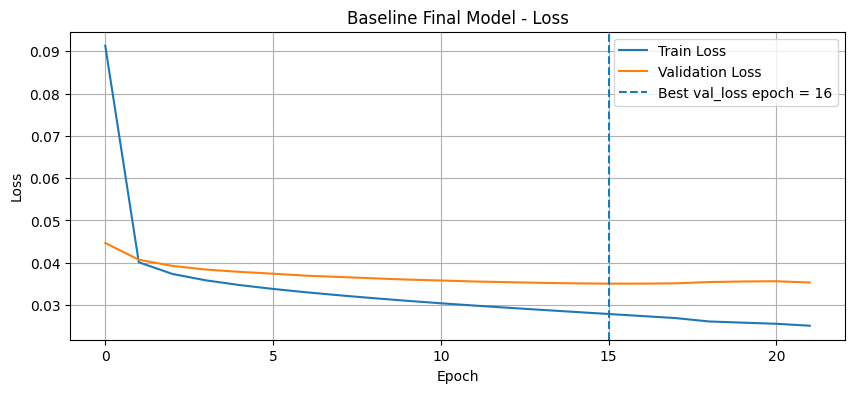

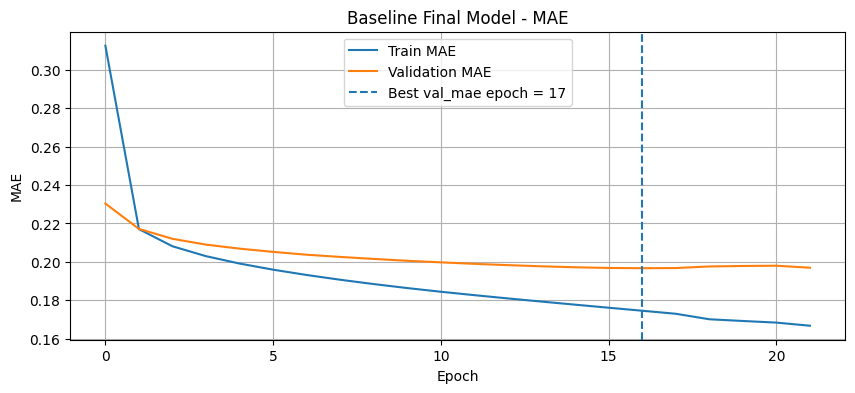

In [74]:
hist = baseline_final_history.history

best_epoch_loss = int(np.argmin(hist["val_loss"])) + 1
best_val_loss = float(np.min(hist["val_loss"]))
best_epoch_mae = int(np.argmin(hist["val_mae"])) + 1
best_val_mae = float(np.min(hist["val_mae"]))

print(f"Best val_loss: {best_val_loss:.6f} (epoch {best_epoch_loss})")
print(f"Best val_mae:  {best_val_mae:.6f} (epoch {best_epoch_mae})")

plt.figure(figsize=(10, 4))
plt.plot(hist["loss"], label="Train Loss")
plt.plot(hist["val_loss"], label="Validation Loss")
plt.axvline(best_epoch_loss - 1, linestyle="--", label=f"Best val_loss epoch = {best_epoch_loss}")
plt.title("Baseline Final Model - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(hist["mae"], label="Train MAE")
plt.plot(hist["val_mae"], label="Validation MAE")
plt.axvline(best_epoch_mae - 1, linestyle="--", label=f"Best val_mae epoch = {best_epoch_mae}")
plt.title("Baseline Final Model - MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.grid(True)
plt.legend()
plt.show()

## Evolutionary

In [75]:
evolutionary_final_history = train_model(
    model=evolutionary_final_model,
    X_train=X_train_e,
    y_train=y_train_e,
    X_val=X_val_e,
    y_val=y_val_e,
    batch_size=evolutionary_cfg_final["batch_size"],
    epochs=30,
    verbose=1,
)

Epoch 1/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.1807 - mae: 0.1804 - val_loss: 0.1533 - val_mae: 0.1530 - learning_rate: 5.0000e-04
Epoch 2/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.1450 - mae: 0.1447 - val_loss: 0.1460 - val_mae: 0.1456 - learning_rate: 5.0000e-04
Epoch 3/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.1395 - mae: 0.1392 - val_loss: 0.1425 - val_mae: 0.1422 - learning_rate: 5.0000e-04
Epoch 4/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.1358 - mae: 0.1355 - val_loss: 0.1408 - val_mae: 0.1404 - learning_rate: 5.0000e-04
Epoch 5/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.1328 - mae: 0.1325 - val_loss: 0.1389 - val_mae: 0.1385 - learning_rate: 5.0000e-04
Epoch 6/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.1302 - mae: 0.1298 - val_loss: 0.1382 - val_mae: 0.1378 - learning_rate: 5.0000e-04
Epoch 7/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.1276 - mae: 0.1273 - val_loss: 0.1376 - val_mae: 0.1372

Best val_loss: 0.136136 (epoch 11)
Best val_mae:  0.135707 (epoch 11)


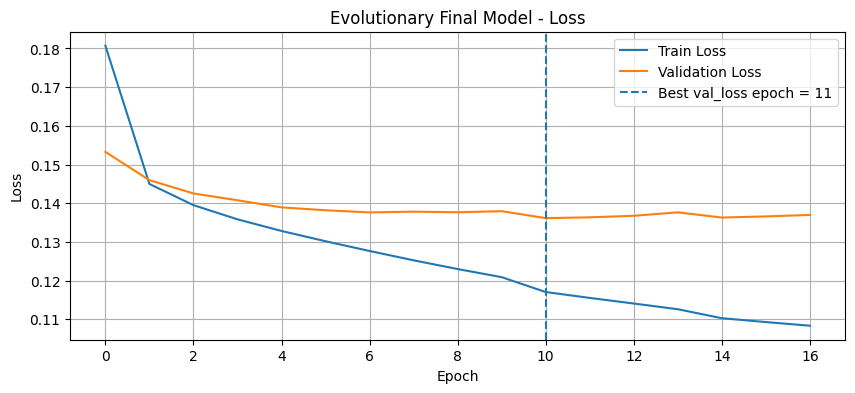

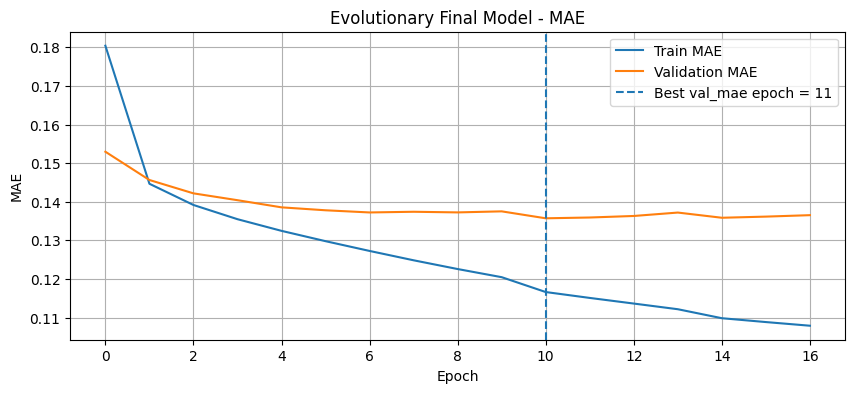

In [76]:
hist = evolutionary_final_history.history

best_epoch_loss = int(np.argmin(hist["val_loss"])) + 1
best_val_loss = float(np.min(hist["val_loss"]))
best_epoch_mae = int(np.argmin(hist["val_mae"])) + 1
best_val_mae = float(np.min(hist["val_mae"]))

print(f"Best val_loss: {best_val_loss:.6f} (epoch {best_epoch_loss})")
print(f"Best val_mae:  {best_val_mae:.6f} (epoch {best_epoch_mae})")

plt.figure(figsize=(10, 4))
plt.plot(hist["loss"], label="Train Loss")
plt.plot(hist["val_loss"], label="Validation Loss")
plt.axvline(best_epoch_loss - 1, linestyle="--", label=f"Best val_loss epoch = {best_epoch_loss}")
plt.title("Evolutionary Final Model - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(hist["mae"], label="Train MAE")
plt.plot(hist["val_mae"], label="Validation MAE")
plt.axvline(best_epoch_mae - 1, linestyle="--", label=f"Best val_mae epoch = {best_epoch_mae}")
plt.title("Evolutionary Final Model - MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.grid(True)
plt.legend()
plt.show()

### 10.3 Final Test Set Evaluation

#### 10.3.1 Test Predictions

In [77]:
y_pred_baseline_test = baseline_final_model.predict(X_test_b, verbose=0)
y_pred_evo_test = evolutionary_final_model.predict(X_test_e, verbose=0)

print("Baseline test prediction shape:", y_pred_baseline_test.shape)
print("Evolutionary test prediction shape:", y_pred_evo_test.shape)

Baseline test prediction shape: (10364, 24)
Evolutionary test prediction shape: (10364, 24)


#### 10.3.2 Test Metrics in Scaled Space

In [78]:
baseline_test_scaled_metrics = evaluate_scaled_forecasts(y_test_b, y_pred_baseline_test)
evo_test_scaled_metrics = evaluate_scaled_forecasts(y_test_e, y_pred_evo_test)

print("Baseline Test MAE (scaled):", baseline_test_scaled_metrics["mae_scaled"])
print("Baseline Test RMSE (scaled):", baseline_test_scaled_metrics["rmse_scaled"])
print("Evolutionary Test MAE (scaled):", evo_test_scaled_metrics["mae_scaled"])
print("Evolutionary Test RMSE (scaled):", evo_test_scaled_metrics["rmse_scaled"])

Baseline Test MAE (scaled): 0.19059740986729293
Baseline Test RMSE (scaled): 0.25233793018192663
Evolutionary Test MAE (scaled): 0.1315283554315162
Evolutionary Test RMSE (scaled): 0.17745266020058742


#### 10.3.3 Test Metrics in Original Temperature Scale

In [81]:
from src.evolution.phenotype import inverse_target_with_scaler

In [82]:
y_test_b_inv = inverse_target_with_scaler(y_test_b, baseline_scaler, target_idx, len(final_feature_cols))
y_pred_baseline_test_inv = inverse_target_with_scaler(y_pred_baseline_test, baseline_scaler, target_idx, len(final_feature_cols))

y_test_e_inv = inverse_target_with_scaler(y_test_e, evo_scaler, target_idx, len(final_feature_cols))
y_pred_evo_test_inv = inverse_target_with_scaler(y_pred_evo_test, evo_scaler, target_idx, len(final_feature_cols))

baseline_test_original_metrics = evaluate_original_scale_forecasts(y_test_b_inv, y_pred_baseline_test_inv)
evo_test_original_metrics = evaluate_original_scale_forecasts(y_test_e_inv, y_pred_evo_test_inv)

print("Baseline Test MAE (°C):", baseline_test_original_metrics["mae"])
print("Baseline Test RMSE (°C):", baseline_test_original_metrics["rmse"])
print("Evolutionary Test MAE (°C):", evo_test_original_metrics["mae"])
print("Evolutionary Test RMSE (°C):", evo_test_original_metrics["rmse"])

Baseline Test MAE (°C): 1.6476372244631565
Baseline Test RMSE (°C): 2.181358955513662
Evolutionary Test MAE (°C): 1.6226762816549014
Evolutionary Test RMSE (°C): 2.1892482566163305


### 10.4 Final Model Comparison

In [83]:
final_model_comparison = pd.DataFrame({
    "Model": ["GRU Baseline Official", "Best Evolutionary GRU"],
    "MAE_scaled": [
        baseline_test_scaled_metrics["mae_scaled"],
        evo_test_scaled_metrics["mae_scaled"],
    ],
    "RMSE_scaled": [
        baseline_test_scaled_metrics["rmse_scaled"],
        evo_test_scaled_metrics["rmse_scaled"],
    ],
    "MAE_degC": [
        baseline_test_original_metrics["mae"],
        evo_test_original_metrics["mae"],
    ],
    "RMSE_degC": [
        baseline_test_original_metrics["rmse"],
        evo_test_original_metrics["rmse"],
    ],
})

final_model_comparison

,Model,MAE_scaled,RMSE_scaled,MAE_degC,RMSE_degC
0,GRU Baseline Official,0.190597,0.252338,1.647637,2.181359
1,Best Evolutionary GRU,0.131528,0.177453,1.622676,2.189248


### 10.5 Final Model Selection

The final comparison between the official GRU baseline and the best evolutionary GRU shows that the evolutionary optimization process was able to find a competitive and slightly better configuration in terms of test MAE.

The official GRU baseline achieved a test MAE of 1.648 °C and an RMSE of 2.181 °C, while the best evolutionary GRU achieved a lower MAE of 1.623 °C, with a very similar RMSE of 2.189 °C.

Although the improvement is modest, the evolutionary model demonstrates that the search process was capable of refining the forecasting configuration beyond the manually fixed baseline. Therefore, the best evolutionary GRU is selected as the final forecasting model for the project.

## 11. Explainable AI

### 11.1 Global Explainability

In [84]:
from src.xai.permutation import permutation_feature_importance

baseline_score, permutation_importances = permutation_feature_importance(
    model=evolutionary_final_model,
    X=X_test_e,
    y=y_test_e,
    feature_names=final_feature_cols,
    n_repeats=3,
    random_state=42,
)

perm_importance_df = pd.DataFrame(permutation_importances).sort_values(
    "importance_mean", ascending=False
)

print("Baseline test MAE used for permutation importance:", baseline_score)
perm_importance_df


Baseline test MAE used for permutation importance: 0.1315283554315162


,feature,importance_mean,importance_std
0,T (degC),0.469833,0.001086
9,doy_cos,0.066664,0.000494
7,hour_cos,0.049569,0.000380
12,wx,0.037257,0.000740
6,hour_sin,0.032855,0.000287
2,rh (%),0.027355,0.000399
1,p (mbar),0.017438,0.000064
4,max. wv (m/s),0.015492,0.000204
10,wd_sin,0.011681,0.000246
14,wind_gap,0.011516,0.000082


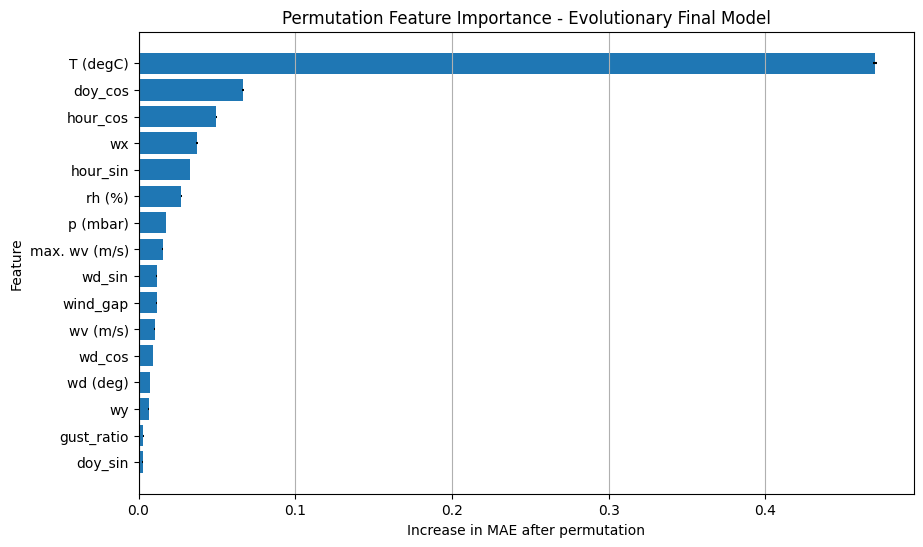

In [85]:
plt.figure(figsize=(10, 6))
plt.barh(
    perm_importance_df["feature"][::-1],
    perm_importance_df["importance_mean"][::-1],
    xerr=perm_importance_df["importance_std"][::-1],
)
plt.title("Permutation Feature Importance - Evolutionary Final Model")
plt.xlabel("Increase in MAE after permutation")
plt.ylabel("Feature")
plt.grid(True, axis="x")
plt.show()

### 11.2 Local Explainability

In [86]:
from src.xai.saliency import (
    compute_saliency_map,
    aggregate_saliency_over_time,
    aggregate_saliency_over_features,
)

In [87]:
sample_idx = 0
input_sample = X_test_e[sample_idx:sample_idx+1]

saliency = compute_saliency_map(
    model=evolutionary_final_model,
    input_sample=input_sample,
    forecast_step=None,
)

print("Saliency shape:", saliency.shape)

saliency = compute_saliency_map(
    model=evolutionary_final_model,
    input_sample=input_sample,
    forecast_step=None,
)

print("Saliency shape:", saliency.shape)

Saliency shape: (120, 16)
Saliency shape: (120, 16)


#### 11.2.1 Feature-Level Local Importance

In [88]:
feature_saliency = aggregate_saliency_over_time(saliency)

local_feature_df = pd.DataFrame({
    "feature": final_feature_cols,
    "saliency": feature_saliency,
}).sort_values("saliency", ascending=False)

local_feature_df

,feature,saliency
0,T (degC),0.008868
1,p (mbar),0.002026
9,doy_cos,0.001952
7,hour_cos,0.001730
2,rh (%),0.001537
4,max. wv (m/s),0.001393
8,doy_sin,0.001221
11,wd_cos,0.001007
5,wd (deg),0.000837
10,wd_sin,0.000832


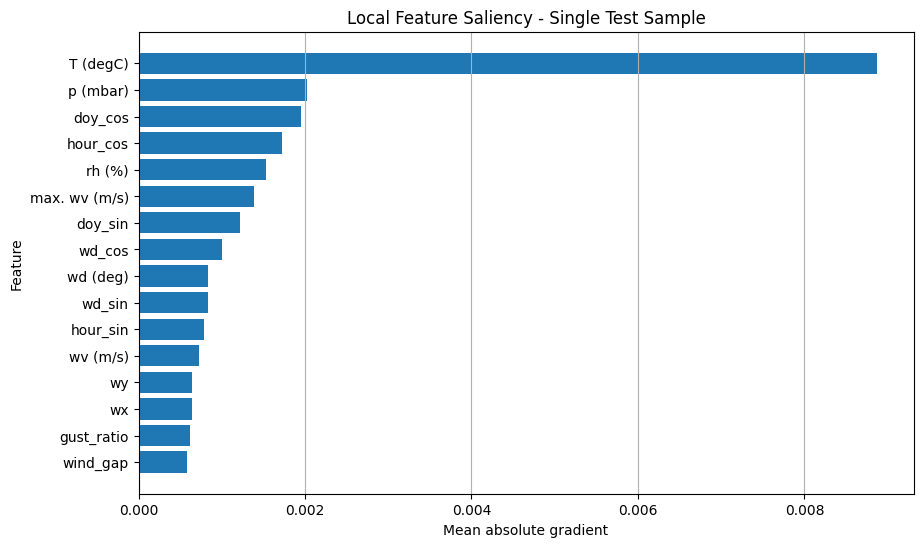

In [89]:
plt.figure(figsize=(10, 6))
plt.barh(local_feature_df["feature"][::-1], local_feature_df["saliency"][::-1])
plt.title("Local Feature Saliency - Single Test Sample")
plt.xlabel("Mean absolute gradient")
plt.ylabel("Feature")
plt.grid(True, axis="x")
plt.show()

#### 11.2.2 Time-Step Local Importance

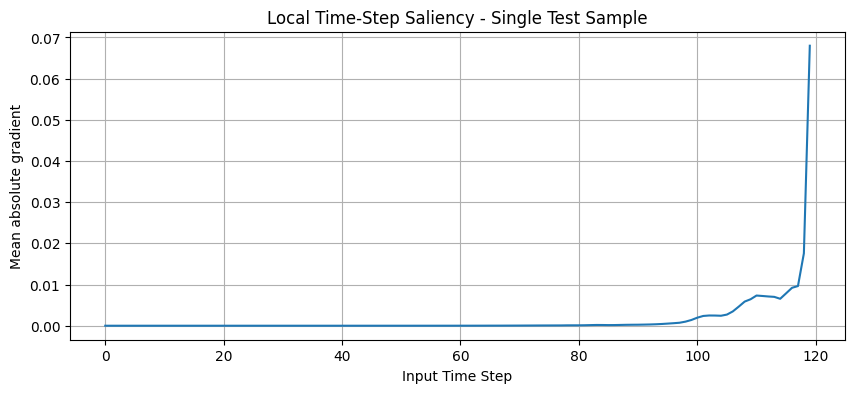

In [90]:
time_saliency = aggregate_saliency_over_features(saliency)

plt.figure(figsize=(10, 4))
plt.plot(time_saliency)
plt.title("Local Time-Step Saliency - Single Test Sample")
plt.xlabel("Input Time Step")
plt.ylabel("Mean absolute gradient")
plt.grid(True)
plt.show()

#### 11.2.3 Saliency Heatmap

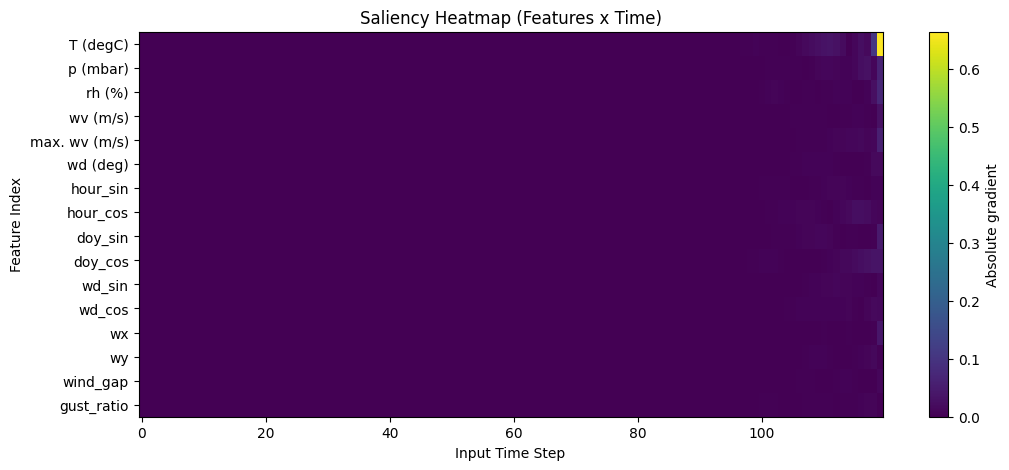

In [91]:
plt.figure(figsize=(12, 5))
plt.imshow(saliency.T, aspect="auto")
plt.title("Saliency Heatmap (Features x Time)")
plt.xlabel("Input Time Step")
plt.ylabel("Feature Index")
plt.yticks(range(len(final_feature_cols)), final_feature_cols)
plt.colorbar(label="Absolute gradient")
plt.show()

### 11.3 XAI Summary

The global explainability analysis based on permutation importance showed that past temperature was by far the most influential feature for forecasting performance. Temporal cyclical features such as `doy_cos`, `hour_cos`, and `hour_sin` also played an important role, indicating that the model captured daily and seasonal structure. Among the meteorological variables, humidity, pressure, and wind-related components also contributed to the predictions.

The local explainability analysis using gradient-based saliency confirmed this pattern at the individual forecast level. For the selected test sample, the most influential inputs were `T (degC)`, `p (mbar)`, `doy_cos`, `hour_cos`, and `rh (%))`. This suggests that the model relied on a combination of recent thermal history, periodic temporal context, and atmospheric conditions.

Overall, the explainability results are consistent with meteorological intuition and support the credibility of the final evolutionary forecasting model.

### 11.4 XAI-Guided Feature Pruning

In [92]:
least_important_5 = perm_importance_df.sort_values("importance_mean", ascending=True).head(5)["feature"].tolist()

print("5 least important features:")
print(least_important_5)

5 least important features:
['doy_sin', 'gust_ratio', 'wy', 'wd (deg)', 'wd_cos']


In [93]:
pruned_feature_cols = [f for f in final_feature_cols if f not in least_important_5]

print("Original number of features:", len(final_feature_cols))
print("Pruned number of features:", len(pruned_feature_cols))
print("Pruned feature set:")
print(pruned_feature_cols)

Original number of features: 16
Pruned number of features: 11
Pruned feature set:
['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'hour_sin', 'hour_cos', 'doy_cos', 'wd_sin', 'wx', 'wind_gap']


In [94]:
pruned_scaler, X_train_p, y_train_p, X_val_p, y_val_p, X_test_p, y_test_p = prepare_data_for_cfg(
    evolutionary_cfg_final,
    df_train,
    df_val,
    df_test,
    pruned_feature_cols,
    target_idx=pruned_feature_cols.index("T (degC)"),
    lookback=LOOKBACK,
    horizon=HORIZON,
)

print("Pruned train shape:", X_train_p.shape, y_train_p.shape)
print("Pruned test shape:", X_test_p.shape, y_test_p.shape)

Pruned train shape: (48885, 120, 11) (48885, 24)
Pruned test shape: (10364, 120, 11) (10364, 24)


In [95]:
pruned_final_model = build_gru_model(
    L=LOOKBACK,
    n_features=X_train_p.shape[2],
    H=HORIZON,
    units1=evolutionary_cfg_final["units1"],
    units2=evolutionary_cfg_final["units2"],
    units3=evolutionary_cfg_final["units3"],
    n_layers=evolutionary_cfg_final["n_layers"],
    dropout=evolutionary_cfg_final["dropout"],
    l2=evolutionary_cfg_final["l2"],
    dense_units=evolutionary_cfg_final["dense_units"],
    dense_activation=evolutionary_cfg_final["dense_activation"],
    learning_rate=evolutionary_cfg_final["learning_rate"],
    clipnorm=evolutionary_cfg_final["clipnorm"],
    optimizer_name=evolutionary_cfg_final["optimizer_name"],
    weight_decay=evolutionary_cfg_final["weight_decay"],
    loss_name=evolutionary_cfg_final["loss_name"],
    gaussian_noise_std=evolutionary_cfg_final["gaussian_noise_std"],
)

pruned_final_history = train_model(
    model=pruned_final_model,
    X_train=X_train_p,
    y_train=y_train_p,
    X_val=X_val_p,
    y_val=y_val_p,
    batch_size=evolutionary_cfg_final["batch_size"],
    epochs=30,
    verbose=1,
)

Epoch 1/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.1804 - mae: 0.1801 - val_loss: 0.1510 - val_mae: 0.1507 - learning_rate: 5.0000e-04
Epoch 2/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.1449 - mae: 0.1446 - val_loss: 0.1443 - val_mae: 0.1440 - learning_rate: 5.0000e-04
Epoch 3/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.1395 - mae: 0.1391 - val_loss: 0.1417 - val_mae: 0.1413 - learning_rate: 5.0000e-04
Epoch 4/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.1360 - mae: 0.1356 - val_loss: 0.1397 - val_mae: 0.1394 - learning_rate: 5.0000e-04
Epoch 5/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.1334 - mae: 0.1330 - val_loss: 0.1390 - val_mae: 0.1386 - learning_rate: 5.0000e-04
Epoch 6/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.1312 - mae: 0.1308 - val_loss: 0.1386 - val_mae: 0.1382 - learning_rate: 5.0000e-04
Epoch 7/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.1293 - mae: 0.1289 - val_loss: 0.1383 - val_mae: 0.137

In [96]:
pruned_final_model = build_gru_model(
    L=LOOKBACK,
    n_features=X_train_p.shape[2],
    H=HORIZON,
    units1=evolutionary_cfg_final["units1"],
    units2=evolutionary_cfg_final["units2"],
    units3=evolutionary_cfg_final["units3"],
    n_layers=evolutionary_cfg_final["n_layers"],
    dropout=evolutionary_cfg_final["dropout"],
    l2=evolutionary_cfg_final["l2"],
    dense_units=evolutionary_cfg_final["dense_units"],
    dense_activation=evolutionary_cfg_final["dense_activation"],
    learning_rate=evolutionary_cfg_final["learning_rate"],
    clipnorm=evolutionary_cfg_final["clipnorm"],
    optimizer_name=evolutionary_cfg_final["optimizer_name"],
    weight_decay=evolutionary_cfg_final["weight_decay"],
    loss_name=evolutionary_cfg_final["loss_name"],
    gaussian_noise_std=evolutionary_cfg_final["gaussian_noise_std"],
)

pruned_final_history = train_model(
    model=pruned_final_model,
    X_train=X_train_p,
    y_train=y_train_p,
    X_val=X_val_p,
    y_val=y_val_p,
    batch_size=evolutionary_cfg_final["batch_size"],
    epochs=30,
    verbose=1,
)

Epoch 1/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.1814 - mae: 0.1811 - val_loss: 0.1518 - val_mae: 0.1515 - learning_rate: 5.0000e-04
Epoch 2/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.1455 - mae: 0.1452 - val_loss: 0.1452 - val_mae: 0.1449 - learning_rate: 5.0000e-04
Epoch 3/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.1401 - mae: 0.1398 - val_loss: 0.1420 - val_mae: 0.1416 - learning_rate: 5.0000e-04
Epoch 4/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.1363 - mae: 0.1360 - val_loss: 0.1404 - val_mae: 0.1401 - learning_rate: 5.0000e-04
Epoch 5/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.1331 - mae: 0.1328 - val_loss: 0.1394 - val_mae: 0.1391 - learning_rate: 5.0000e-04
Epoch 6/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.1306 - mae: 0.1302 - val_loss: 0.1390 - val_mae: 0.1386 - learning_rate: 5.0000e-04
Epoch 7/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.1285 - mae: 0.1281 - val_loss: 0.1388 - val_mae: 0.1384

In [97]:
y_pred_pruned_test = pruned_final_model.predict(X_test_p, verbose=0)

pruned_test_scaled_metrics = evaluate_scaled_forecasts(y_test_p, y_pred_pruned_test)

y_test_p_inv = inverse_target_with_scaler(
    y_test_p, pruned_scaler, pruned_feature_cols.index("T (degC)"), len(pruned_feature_cols)
)
y_pred_pruned_test_inv = inverse_target_with_scaler(
    y_pred_pruned_test, pruned_scaler, pruned_feature_cols.index("T (degC)"), len(pruned_feature_cols)
)

pruned_test_original_metrics = evaluate_original_scale_forecasts(y_test_p_inv, y_pred_pruned_test_inv)

print("Pruned Model Test MAE (scaled):", pruned_test_scaled_metrics["mae_scaled"])
print("Pruned Model Test RMSE (scaled):", pruned_test_scaled_metrics["rmse_scaled"])
print("Pruned Model Test MAE (°C):", pruned_test_original_metrics["mae"])
print("Pruned Model Test RMSE (°C):", pruned_test_original_metrics["rmse"])

Pruned Model Test MAE (scaled): 0.130006447070858
Pruned Model Test RMSE (scaled): 0.17598322854705564
Pruned Model Test MAE (°C): 1.6039003713837645
Pruned Model Test RMSE (°C): 2.1711197558540714


In [98]:
xai_pruning_comparison = pd.DataFrame({
    "Model": ["Best Evolutionary GRU", "Pruned Evolutionary GRU"],
    "Num_Features": [len(final_feature_cols), len(pruned_feature_cols)],
    "MAE_scaled": [
        evo_test_scaled_metrics["mae_scaled"],
        pruned_test_scaled_metrics["mae_scaled"],
    ],
    "RMSE_scaled": [
        evo_test_scaled_metrics["rmse_scaled"],
        pruned_test_scaled_metrics["rmse_scaled"],
    ],
    "MAE_degC": [
        evo_test_original_metrics["mae"],
        pruned_test_original_metrics["mae"],
    ],
    "RMSE_degC": [
        evo_test_original_metrics["rmse"],
        pruned_test_original_metrics["rmse"],
    ],
})

xai_pruning_comparison

,Model,Num_Features,MAE_scaled,RMSE_scaled,MAE_degC,RMSE_degC
0,Best Evolutionary GRU,16,0.131528,0.177453,1.622676,2.189248
1,Pruned Evolutionary GRU,11,0.130006,0.175983,1.603900,2.171120


### 11.5 Effect of XAI-Guided Feature Pruning

The XAI-guided pruning experiment removed the five least important features identified by permutation importance and retrained the best evolutionary GRU using the reduced feature set.

This pruning step reduced the number of input variables from 16 to 11 and led to a small but consistent improvement across all evaluation metrics. The pruned evolutionary GRU achieved a test MAE of 1.604 °C and an RMSE of 2.171 °C, improving over the original evolutionary model, which obtained 1.623 °C MAE and 2.189 °C RMSE.

These results suggest that the least important variables were either redundant or slightly noisy for the final forecasting task. Therefore, XAI was not only useful for interpretation, but also for feature selection and model refinement.

## 12. Efficiency, Latency and Resource Analysis

### 12.1 Motivation

Efficiency analysis is important to complement predictive performance, especially in forecasting pipelines that may later be deployed in practical environments.

In this project, efficiency is assessed through three aspects:
1. model complexity, measured by the number of trainable parameters
2. inference latency, measured on the available hardware
3. the trade-off between predictive accuracy and computational cost

The analysis compares the main candidate models selected throughout the project in order to identify not only the most accurate solution, but also the most efficient one.

### 12.2 Models Selected for Efficiency Analysis

In [99]:
efficiency_models = {
    "GRU Baseline Official": baseline_final_model,
    "Best Evolutionary GRU": evolutionary_final_model,
    "Pruned Evolutionary GRU": pruned_final_model,
}

list(efficiency_models.keys())

['GRU Baseline Official', 'Best Evolutionary GRU', 'Pruned Evolutionary GRU']

### 12.3 Trainable Parameters

In [100]:
from src.utils.profiling import count_trainable_params

param_results = []

for model_name, model in efficiency_models.items():
    param_results.append({
        "Model": model_name,
        "Trainable_Params": count_trainable_params(model),
    })

param_results_df = pd.DataFrame(param_results)
param_results_df

,Model,Trainable_Params
0,GRU Baseline Official,86744
1,Best Evolutionary GRU,128920
2,Pruned Evolutionary GRU,127000


### 12.4 Inference Latency

In [103]:
from src.utils.profiling import measure_inference_latency
import inspect

print(inspect.signature(measure_inference_latency))

(model: keras.src.models.model.Model, sample_input: Any, n_warmup: int = 10, n_runs: int = 30) -> Dict[str, float]


In [105]:
from src.utils.profiling import measure_inference_latency

latency_results = []

latency_inputs = {
    "GRU Baseline Official": X_test_b[:256],
    "Best Evolutionary GRU": X_test_e[:256],
    "Pruned Evolutionary GRU": X_test_p[:256],
}

for model_name, model in efficiency_models.items():
    latency_metrics = measure_inference_latency(
        model=model,
        sample_input=latency_inputs[model_name],
        n_warmup=5,
        n_runs=10,
    )
    latency_results.append({
        "Model": model_name,
        **latency_metrics,
    })

latency_results_df = pd.DataFrame(latency_results)
latency_results_df

,Model,latency_mean_ms,latency_std_ms,latency_p50_ms,latency_p95_ms,throughput_samples_s
0,GRU Baseline Official,13.955995,1.196691,14.189206,15.549907,18343.371703
1,Best Evolutionary GRU,11.299695,0.420212,11.213530,11.969754,22655.477951
2,Pruned Evolutionary GRU,11.250533,0.663149,11.201556,12.279172,22754.477086


### 12.5 Efficiency Comparison

In [106]:
efficiency_comparison = final_model_comparison.merge(
    param_results_df,
    on="Model"
).merge(
    latency_results_df[[
        "Model",
        "latency_mean_ms",
        "latency_std_ms",
        "latency_p50_ms",
        "latency_p95_ms",
        "throughput_samples_s",
    ]],
    on="Model"
)

efficiency_comparison

,Model,MAE_scaled,RMSE_scaled,MAE_degC,RMSE_degC,Trainable_Params,latency_mean_ms,latency_std_ms,latency_p50_ms,latency_p95_ms,throughput_samples_s
0,GRU Baseline Official,0.190597,0.252338,1.647637,2.181359,86744,13.955995,1.196691,14.189206,15.549907,18343.371703
1,Best Evolutionary GRU,0.131528,0.177453,1.622676,2.189248,128920,11.299695,0.420212,11.213530,11.969754,22655.477951


### 12.6 Final Efficiency Discussion

The efficiency analysis showed that the evolutionary models were not only competitive in predictive accuracy, but also more efficient at inference time than the official GRU baseline.

The official GRU baseline had the highest latency, with an average inference time of about 13.96 ms per batch and the lowest throughput. In contrast, the best evolutionary GRU reduced latency to about 11.30 ms, and the pruned evolutionary GRU achieved the best efficiency overall, with approximately 11.25 ms average latency and the highest throughput.

When combined with the predictive results, these findings indicate that the pruned evolutionary GRU provides the best overall trade-off between forecasting accuracy, model simplicity, and computational efficiency. Therefore, it is selected as the final model of the project.

## 13. Comparative Discussion

## 14. Conclusion